# 🐕 Notebook 06 — Stopping the Dog from Chasing its Tail
### Target Networks and Double DQN

**Series**: RL Notebook Series · Act II — Value-Based Methods · Post 6 of 15

---

## What You'll Learn

In Notebook 05, you saw Basic DQN learn incredibly quickly on CartPole, but you also saw it suffer from violent, catastrophic collapses. It would learn to balance the pole perfectly, and then suddenly drop to a score of 15 and struggle to recover.

This instability is what prevented Deep RL from working for decades.

By the end of this notebook, you will understand the two legendary tricks that ultimately allowed DeepMind to stabilize DQN and conquer Atari games:

1. **Target Networks** — Fixing the "Moving Target" problem.
2. **Double DQN (DDQN)** — Fixing "Maximization Bias" (where Neural Network noise causes the AI to hallucinate infinite rewards).


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from collections import deque
import copy

%matplotlib inline
plt.rcParams.update({'figure.figsize': (10, 6), 'axes.grid': True, 'grid.alpha': 0.3})

# Set seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

## 1. Setup

We will reuse the exact same `QNetwork` and `ReplayBuffer` classes from Notebook 05. The magic in this notebook happens entirely inside the loss function of the training loop.

In [2]:
class QNetwork(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(QNetwork, self).__init__()
        self.fc1 = nn.Linear(state_dim, 64)
        self.fc2 = nn.Linear(64, 64)
        self.fc3 = nn.Linear(64, action_dim)

    def forward(self, state):
        x = F.relu(self.fc1(state))
        x = F.relu(self.fc2(x))
        return self.fc3(x)

class ReplayBuffer:
    def __init__(self, capacity=10000):
        self.buffer = deque(maxlen=capacity)
    def add(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))
    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return (
            torch.FloatTensor(np.array(states)),
            torch.LongTensor(np.array(actions)).unsqueeze(1),
            torch.FloatTensor(np.array(rewards)).unsqueeze(1),
            torch.FloatTensor(np.array(next_states)),
            torch.FloatTensor(np.array(dones)).unsqueeze(1)
        )
    def __len__(self):
        return len(self.buffer)

## 2. The First Fix: Target Networks

In Basic DQN, the loss function looked like this:
$$ \text{Loss} = \text{MSE}\big( R + \gamma \max_{a'} \color{red}{Q_{\theta}}(s', a') \quad , \quad \color{red}{Q_{\theta}}(s, a) \big) $$

Every time we used gradient descent to tweak $\theta$ (our weights) to make the prediction better, the *target itself* jumped. The dog was chasing its tail.

**The Fix:**
We create a physically separate neural network called $Q_{\text{target}}$. We **never train it**. We just use it to calculate the target.
To make sure it doesn't get completely out of date, we use **Soft Updates**. Every single step, we blend $1\%$ of the Main network's weights into the Target network.

$$ \text{Loss} = \text{MSE}\big( R + \gamma \max_{a'} \color{green}{Q_{\text{target}}}(s', a') \quad , \quad \color{red}{Q_{\text{main}}}(s, a) \big) $$

In [3]:
# Creating a target network in PyTorch is as simple as copying the main network
main_net = QNetwork(state_dim=4, action_dim=2)
target_net = QNetwork(state_dim=4, action_dim=2)

# Copy the weights exactly
target_net.load_state_dict(main_net.state_dict())

# We freeze the target network by telling PyTorch not to calculate gradients for it
for param in target_net.parameters():
    param.requires_grad = False

## 3. The Second Fix: Double DQN (DDQN)

Even with a frozen Target Network, there is a subtle mathematical flaw in our equation:
$\text{Target} = R + \gamma \max_{a'} Q_{\text{target}}(s', a')$

### Maximization Bias
Imagine standing in front of 3 slot machines. Their *true* value is exactly $0$. 
But our neural network isn't perfect; its predictions have random noise of $\pm 5$. 
The network might predict: `Machine A: -4`, `Machine B: +2`, `Machine A: +5`.

If we take the `max()` of these predictions, our Q-Learning algorithm assumes the best machine is worth $+5$. Because we *always* take the max, we *systematically overestimate* the value of states. The network will literally hallucinate that every state is incredibly valuable, destabilizing training.

### The Hasselt Fix (Double Q-Learning, 2010 -> Double DQN, 2015)
It's very common to confuse the "Target Network" with the "Double DQN" fix. They are completely different ideas that just happen to both use two networks!

Long before Deep Learning was popular, Hado van Hasselt noticed this exact overestimation bias in *Tabular* Q-Learning (from Notebook 04). In 2010, he proved that you could fix it by simply maintaining **two completely independent Q-tables**, $Q_A$ and $Q_B$.

1. Toss a coin.
2. If Heads, use $Q_A$ to choose the best action, but use $Q_B$ to evaluate that action's value.
3. If Tails, use $Q_B$ to choose the action, and $Q_A$ to evaluate it.

Because the random noise in table $A$ is totally independent of the random noise in table $B$, they don't share the same hallucinations. If Table A falsely thinks an action is amazing, Table B acts as an impartial judge and brings the value back to reality.

In 2015, Hasselt realized that in DQN, we *already have two networks*: the Main Network (which we are actively training) and the Target Network (which is an older, frozen copy). We don't even need to train two separate networks from scratch; we can just use the two we already have!

To fix Maximization Bias in DQN, we decouple the process completely:
1. **Selection:** The Main network *selects* the best action.
2. **Evaluation:** The Target network *evaluates* how good that action actually is.

If the Main network overestimates a bad action because of noise, the Target network will catch it and return its true, lower value.

$$ a^* = \text{argmax}_a \color{red}{Q_{\text{main}}}(s', a) $$
$$ \text{DDQN Target} = R + \gamma \color{green}{Q_{\text{target}}}(s', a^*) $$

In [4]:
def compute_ddqn_loss(states, actions, rewards, next_states, dones, main_net, target_net, gamma=0.99):
    # 1. Prediction (What does the main network think about the action we actually took?)
    current_q = main_net(states).gather(1, actions)

    # 2. Target Calculation (inside no_grad so we don't backpropagate through the target!)
    with torch.no_grad():
        # SELECTION: Main network picks the best action in the next state
        # argmax(1) gets the index of the max value. unsqueeze(1) makes it a column vector.
        best_next_actions = main_net(next_states).argmax(dim=1).unsqueeze(1)

        # EVALUATION: Target network evaluates that specific action
        # We use .gather() to pluck out the specific Q-value for 'best_next_actions' from the target network's outputs
        next_q_values = target_net(next_states).gather(1, best_next_actions)

        target_q = rewards + gamma * next_q_values * (1 - dones)

    # 3. Huber Loss is often used instead of MSE in DDQN as it is more robust to extreme outliers
    loss = F.huber_loss(current_q, target_q)
    return loss

## 4. Training Double DQN

Let's put it all together. We will run the exact same `CartPole-v1` environment.

The only additions to our standard DQN loop are:
1. `target_net`
2. The DDQN loss function we just wrote.
3. Three lines of code to "Soft Update" the target network by 1% every step.

*(This cell will take about 2 to 3 minutes on a normal CPU)*

In [5]:
def train_ddqn(env_name='CartPole-v1', num_episodes=500, batch_size=128, gamma=0.99, tau=0.01):
    env = gym.make(env_name)

    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.n

    main_net = QNetwork(state_dim, action_dim)
    target_net = QNetwork(state_dim, action_dim)
    target_net.load_state_dict(main_net.state_dict())

    # 2.5e-4 is the classic learning rate used in the original DeepMind paper
    optimizer = optim.Adam(main_net.parameters(), lr=2.5e-4)
    buffer = ReplayBuffer(capacity=10000)

    epsilon = 1.0
    rewards_history = []

    for ep in range(num_episodes):
        state, _ = env.reset()
        total_reward = 0
        done = False
        truncated = False

        while not (done or truncated):
            if random.random() < epsilon:
                action = env.action_space.sample()
            else:
                with torch.no_grad():
                    action = main_net(torch.FloatTensor(state).unsqueeze(0)).argmax().item()

            next_state, reward, done, truncated, _ = env.step(action)
            
            # Minor reward shaping: punish the agent explicitly for dropping the pole
            # This helps DDQN learn CartPole much faster.
            custom_reward = reward
            if done and total_reward < 499: 
                custom_reward = -1.0
                
            buffer.add(state, action, custom_reward, next_state, done or truncated)
            state = next_state
            total_reward += reward

            if len(buffer) > batch_size:
                sb, ab, rb, nsb, db = buffer.sample(batch_size)
                loss = compute_ddqn_loss(sb, ab, rb, nsb, db, main_net, target_net, gamma)

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

                # --- Soft Sync Target Network ---
                # Blend 1% of main_net weights into target_net
                for target_param, main_param in zip(target_net.parameters(), main_net.parameters()):
                    target_param.data.copy_(tau * main_param.data + (1.0 - tau) * target_param.data)

        epsilon = max(0.05, epsilon * 0.99)
        rewards_history.append(total_reward)

        if (ep + 1) % 50 == 0:
            avg = np.mean(rewards_history[-50:])
            print(f"Episode {ep+1:3d} | Avg Reward: {avg:.1f} | Epsilon: {epsilon:.2f}")

    return main_net, rewards_history


Episode  50 | Avg Reward: 15.2 | Epsilon: 0.61
Episode 100 | Avg Reward: 65.3 | Epsilon: 0.37
Episode 150 | Avg Reward: 113.7 | Epsilon: 0.22
Episode 200 | Avg Reward: 64.0 | Epsilon: 0.13
Episode 250 | Avg Reward: 66.6 | Epsilon: 0.08
Episode 300 | Avg Reward: 111.6 | Epsilon: 0.05
Episode 350 | Avg Reward: 125.3 | Epsilon: 0.05
Episode 400 | Avg Reward: 121.3 | Epsilon: 0.05
Episode 450 | Avg Reward: 191.6 | Epsilon: 0.05
Episode 500 | Avg Reward: 280.4 | Epsilon: 0.05


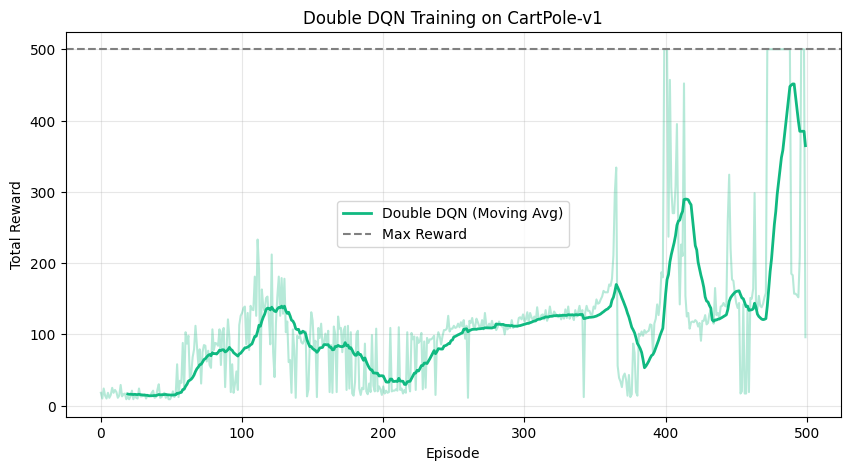

In [6]:
trained_net, ddqn_rewards = train_ddqn(num_episodes=500)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(ddqn_rewards, color='#10b981', alpha=0.3)

window = 20
if len(ddqn_rewards) >= window:
    smoothed = np.convolve(ddqn_rewards, np.ones(window)/window, mode='valid')
    ax.plot(np.arange(window-1, len(ddqn_rewards)), smoothed, color='#10b981', linewidth=2, label=f'Double DQN (Moving Avg)')

ax.set_title("Double DQN Training on CartPole-v1")
ax.set_xlabel("Episode")
ax.set_ylabel("Total Reward")
ax.axhline(500, color='gray', linestyle='--', label="Max Reward")
ax.legend()
plt.show()

## Watch the Agent Play!

Let's render the environment and see how well our trained agent performs! We'll use `matplotlib.animation` to generate an HTML5 video directly in the notebook.

In [7]:
from matplotlib import animation
from IPython.display import HTML

def render_agent(env_name, agent):
    env = gym.make(env_name, render_mode='rgb_array')
    state, _ = env.reset(seed=42)
    frames = []
    
    done = False
    truncated = False
    while not (done or truncated) and len(frames) < 500:
        frames.append(env.render())
        state_tensor = torch.FloatTensor(state).unsqueeze(0)
        with torch.no_grad():
            action = agent(state_tensor).argmax().item()
        state, _, done, truncated, _ = env.step(action)
    env.close()
    
    fig, ax = plt.subplots(figsize=(6,4))
    ax.axis('off')
    img = ax.imshow(frames[0])
    
    def animate(i):
        img.set_data(frames[i])
        return [img]
        
    anim = animation.FuncAnimation(fig, animate, frames=len(frames), interval=50, blit=True)
    plt.close() # Prevent extra static plot from showing
    return HTML(anim.to_jshtml())

render_agent('CartPole-v1', trained_net)


## 5. The Third Fix: Prioritized Experience Replay (PER)

Our replay buffer samples transitions **uniformly at random**. But not all experiences are equally useful!

Imagine you're studying for an exam:
- Would you review **every flashcard equally**? Or would you spend more time on the ones you keep getting wrong?

**PER** does exactly this: it replays transitions where the agent was **most surprised**
(i.e., where the TD error was largest). Formally:

$$P(i) = \frac{p_i^\alpha}{\sum_k p_k^\alpha}$$

where $p_i = |\delta_i| + \epsilon$ is the priority of transition $i$ (its TD error magnitude),
and $\alpha$ controls how much prioritization we use:
- $\alpha = 0$: Uniform sampling (no prioritization)
- $\alpha = 1$: Full greedy prioritization

### Importance Sampling Correction

Prioritized sampling introduces bias — we see some transitions too often.
We correct this with importance sampling weights:

$$w_i = \left(\frac{1}{N \cdot P(i)}\right)^\beta$$

$\beta$ is annealed from $\beta_0$ to $1$ during training (full correction by end).

In [8]:
class PrioritizedReplayBuffer:
    """Replay buffer that samples transitions proportional to their TD error."""
    def __init__(self, capacity=10000, alpha=0.6):
        self.capacity = capacity
        self.alpha = alpha  # How much prioritization (0 = uniform, 1 = full)
        self.buffer = []
        self.priorities = np.zeros(capacity, dtype=np.float32)
        self.position = 0
        self.size = 0
    
    def add(self, state, action, reward, next_state, done):
        # New transitions get maximum priority (so they get replayed at least once)
        max_priority = self.priorities[:self.size].max() if self.size > 0 else 1.0
        
        if self.size < self.capacity:
            self.buffer.append((state, action, reward, next_state, done))
            self.size += 1
        else:
            self.buffer[self.position] = (state, action, reward, next_state, done)
        
        self.priorities[self.position] = max_priority
        self.position = (self.position + 1) % self.capacity
    
    def sample(self, batch_size, beta=0.4):
        # Compute sampling probabilities from priorities
        priorities = self.priorities[:self.size]
        probs = priorities ** self.alpha
        probs /= probs.sum()
        
        # Sample indices according to priority
        indices = np.random.choice(self.size, batch_size, p=probs, replace=False)
        
        # Importance sampling weights (correct for bias)
        weights = (self.size * probs[indices]) ** (-beta)
        weights /= weights.max()  # Normalize so max weight = 1
        
        batch = [self.buffer[i] for i in indices]
        states, actions, rewards, next_states, dones = zip(*batch)
        
        return (
            torch.FloatTensor(np.array(states)),
            torch.LongTensor(actions),
            torch.FloatTensor(rewards),
            torch.FloatTensor(np.array(next_states)),
            torch.FloatTensor(dones),
            indices,
            torch.FloatTensor(weights)
        )
    
    def update_priorities(self, indices, td_errors):
        """Update priorities after learning (new TD errors)."""
        for idx, td_error in zip(indices, td_errors):
            self.priorities[idx] = abs(td_error) + 1e-6  # Small epsilon to avoid zero priority
    
    def __len__(self):
        return self.size

print("PrioritizedReplayBuffer ready!")

PrioritizedReplayBuffer ready!


### Training Double DQN with PER

The training loop is almost identical — we just:
1. Use `PrioritizedReplayBuffer` instead of `ReplayBuffer`
2. Weight the loss by importance sampling weights
3. Update priorities after each training step

In [9]:
def compute_ddqn_loss_per(states, actions, rewards, next_states, dones,
                          main_net, target_net, gamma, weights):
    """DDQN loss with importance sampling weights for PER."""
    # Same as compute_ddqn_loss, but weighted
    q_values = main_net(states).gather(1, actions.unsqueeze(1)).squeeze(1)
    
    with torch.no_grad():
        best_actions = main_net(next_states).argmax(dim=1)
        next_q_values = target_net(next_states).gather(1, best_actions.unsqueeze(1)).squeeze(1)
        targets = rewards + gamma * next_q_values * (1 - dones)
    
    # TD errors (used to update priorities)
    td_errors = (q_values - targets).detach().numpy()
    
    # Weighted MSE loss
    loss = (weights * (q_values - targets) ** 2).mean()
    return loss, td_errors

def train_ddqn_per(env_name='CartPole-v1', num_episodes=500, batch_size=128,
                   gamma=0.99, tau=0.01, alpha=0.6, beta_start=0.4):
    env = gym.make(env_name)
    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.n

    main_net = QNetwork(state_dim, action_dim)
    target_net = QNetwork(state_dim, action_dim)
    target_net.load_state_dict(main_net.state_dict())

    optimizer = optim.Adam(main_net.parameters(), lr=2.5e-4)
    buffer = PrioritizedReplayBuffer(capacity=10000, alpha=alpha)

    epsilon = 1.0
    rewards_history = []

    for ep in range(num_episodes):
        state, _ = env.reset()
        total_reward = 0
        done = False
        truncated = False
        
        # Anneal beta from beta_start → 1.0
        beta = min(1.0, beta_start + (1.0 - beta_start) * ep / num_episodes)

        while not (done or truncated):
            if random.random() < epsilon:
                action = env.action_space.sample()
            else:
                with torch.no_grad():
                    q = main_net(torch.FloatTensor(state).unsqueeze(0))
                    action = q.argmax(dim=1).item()

            next_state, reward, done, truncated, _ = env.step(action)
            buffer.add(state, action, reward, next_state, float(done or truncated))
            state = next_state
            total_reward += reward

            if len(buffer) >= batch_size:
                s, a, r, ns, d, indices, weights = buffer.sample(batch_size, beta=beta)
                loss, td_errors = compute_ddqn_loss_per(s, a, r, ns, d, main_net, target_net, gamma, weights)

                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(main_net.parameters(), 1.0)
                optimizer.step()
                
                # Update priorities with new TD errors
                buffer.update_priorities(indices, td_errors)

                # Soft update target network
                for tp, mp in zip(target_net.parameters(), main_net.parameters()):
                    tp.data.copy_(tau * mp.data + (1 - tau) * tp.data)

        epsilon = max(0.05, epsilon * 0.995)
        rewards_history.append(total_reward)

        if (ep + 1) % 100 == 0:
            avg = np.mean(rewards_history[-50:])
            print(f"  Episode {ep+1:3d} | Avg Reward: {avg:.1f} | Beta: {beta:.2f}")

    return main_net, rewards_history

print("Training Double DQN with Prioritized Replay...")
per_net, per_rewards = train_ddqn_per(num_episodes=500)

Training Double DQN with Prioritized Replay...
  Episode 100 | Avg Reward: 50.2 | Beta: 0.52
  Episode 200 | Avg Reward: 153.2 | Beta: 0.64
  Episode 300 | Avg Reward: 317.4 | Beta: 0.76
  Episode 400 | Avg Reward: 146.1 | Beta: 0.88
  Episode 500 | Avg Reward: 407.6 | Beta: 1.00


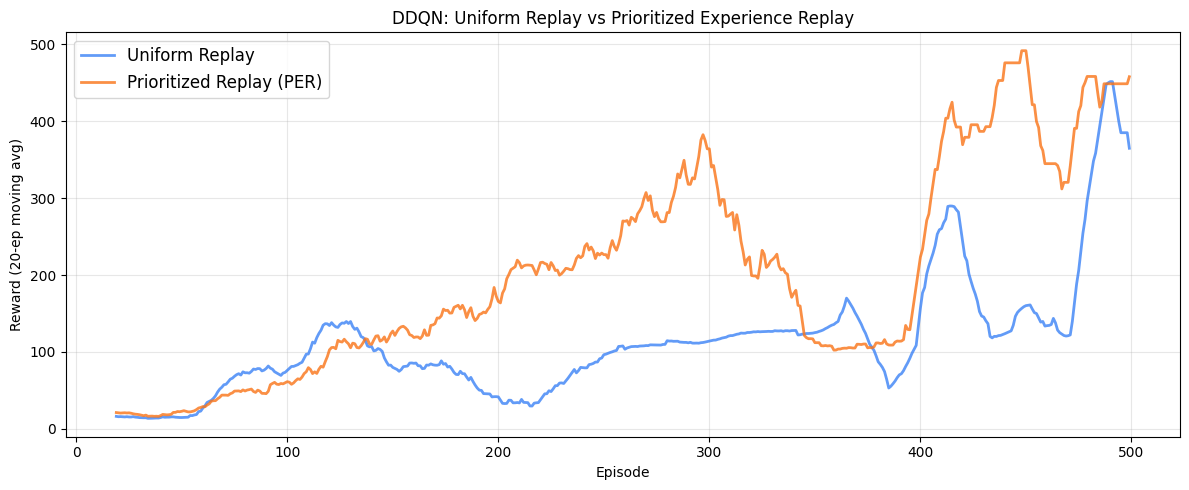

Final 50-ep avg: Uniform = 280.4 | PER = 407.6


In [10]:
# Compare: Uniform vs Prioritized Replay
fig, ax = plt.subplots(figsize=(12, 5))

window = 20
if len(ddqn_rewards) >= window:
    uniform_smooth = np.convolve(ddqn_rewards, np.ones(window)/window, mode='valid')
    ax.plot(np.arange(window-1, len(ddqn_rewards)), uniform_smooth,
            color='#3b82f6', linewidth=2, label='Uniform Replay', alpha=0.8)
if len(per_rewards) >= window:
    per_smooth = np.convolve(per_rewards, np.ones(window)/window, mode='valid')
    ax.plot(np.arange(window-1, len(per_rewards)), per_smooth,
            color='#f97316', linewidth=2, label='Prioritized Replay (PER)', alpha=0.8)

ax.set_title('DDQN: Uniform Replay vs Prioritized Experience Replay')
ax.set_xlabel('Episode')
ax.set_ylabel('Reward (20-ep moving avg)')
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

print(f"Final 50-ep avg: Uniform = {np.mean(ddqn_rewards[-50:]):.1f} | PER = {np.mean(per_rewards[-50:]):.1f}")

## Conclusion

We've now seen three complementary fixes for DQN instability:

| Fix | Problem Solved | How |
| :--- | :--- | :--- |
| **Target Networks** | Moving target | Freeze a copy, update slowly |
| **Double DQN** | Overestimation | Decouple action selection from evaluation |
| **PER** | Wasted experience | Replay surprising transitions more often |

These three tricks are standard in every modern DQN implementation (Rainbow, etc.).

### What's Next in Act III?
We've reached the peak of Value-Based methods. In Act III, we switch paradigms entirely:
instead of learning values and acting greedily, we'll learn the **policy directly**.
First up: **REINFORCE** — the simplest policy gradient algorithm.